   Complaint number                            Complaint filed against  \
0                 1                METROPOLITAN LIFE INSURANCE COMPANY   
1                 2                       AETNA LIFE INSURANCE COMPANY   
2                 3  BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISIO...   
3                 4  BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISIO...   
4                 5            CHARTER OAK FIRE INSURANCE COMPANY, THE   

  Complaint filed by       Reason complaint filed Confirmed complaint  \
0           Relative  Cust Service Claim Handling                  No   
1           Provider     Delays (Claims Handling)                  No   
2           Provider              Denial Of Claim                  No   
3           Provider              Denial Of Claim                  No   
4            Insured  Unsatisfactory Settle/Offer                  No   

                                      How resolved Received date Closed date  \
0                                   

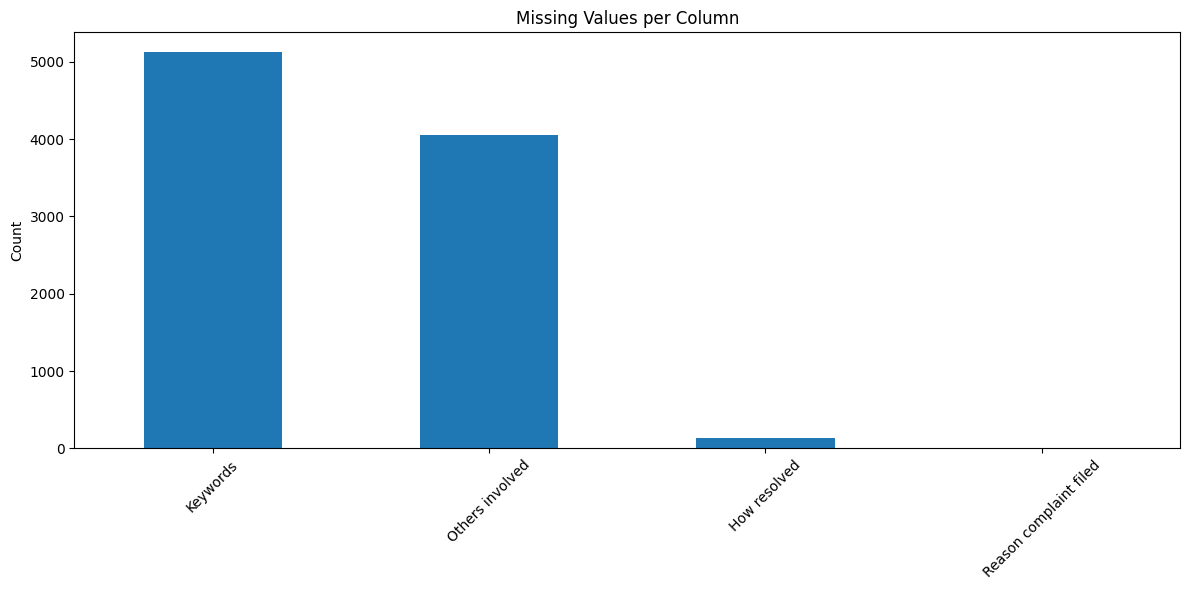

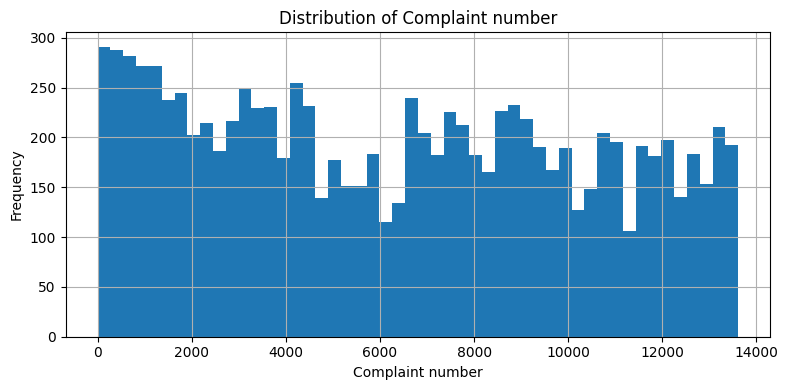

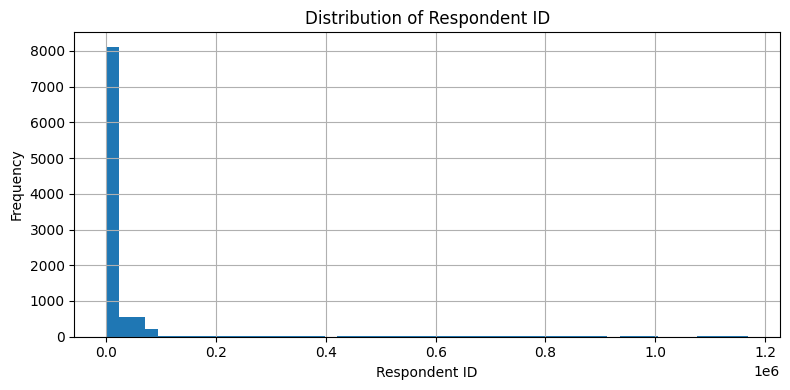

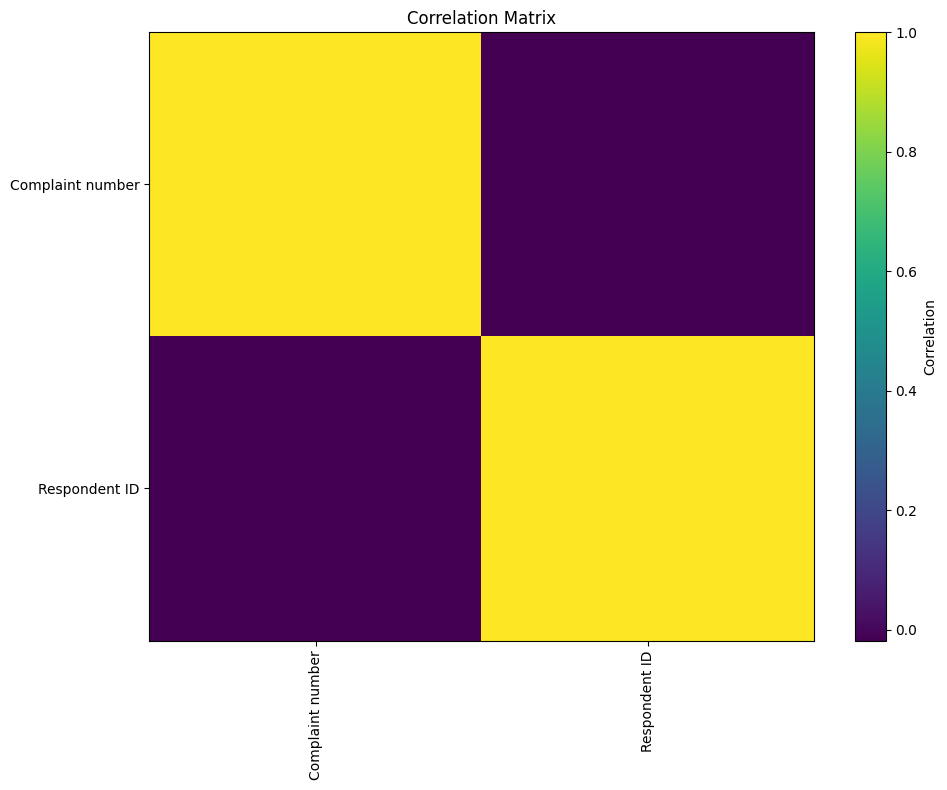

/tmp/ipykernel_1325350/2423549279.py:64: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = sample.select_dtypes(include='object').columns
/tmp/ipykernel_1325350/2423549279.py:74: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


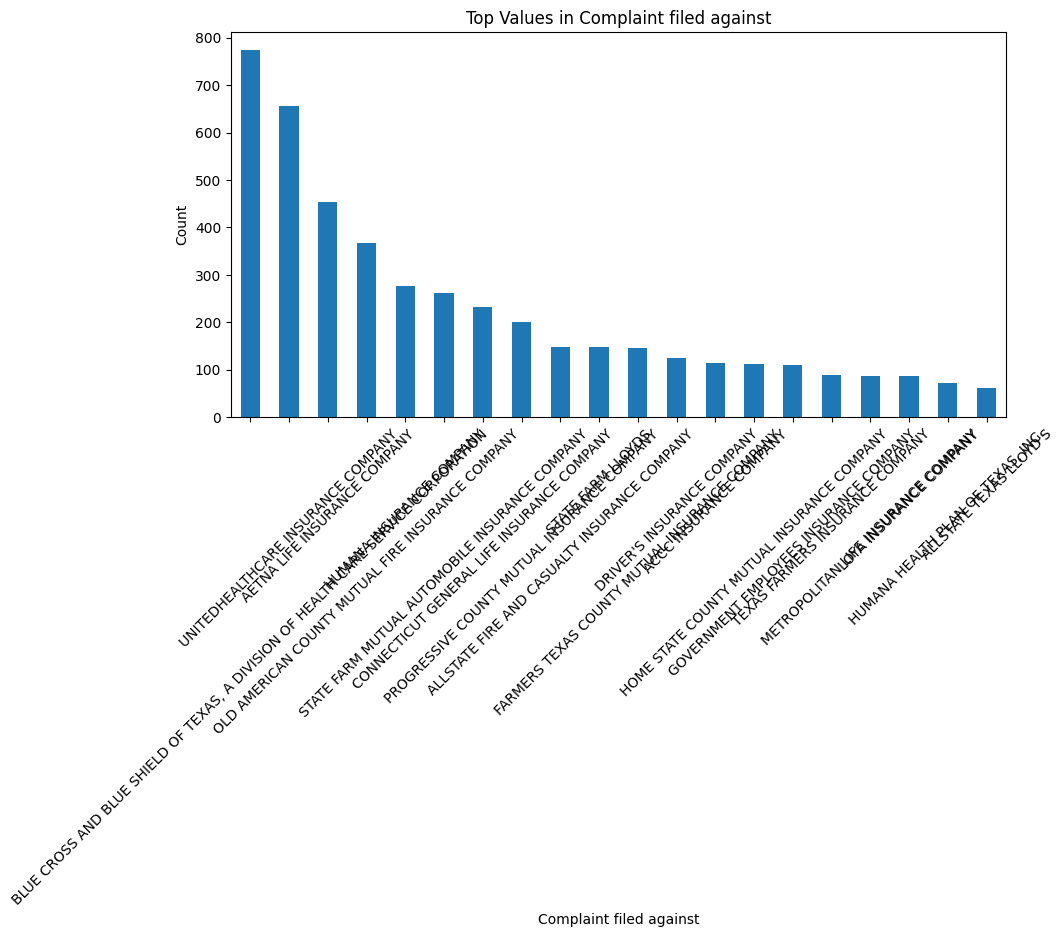

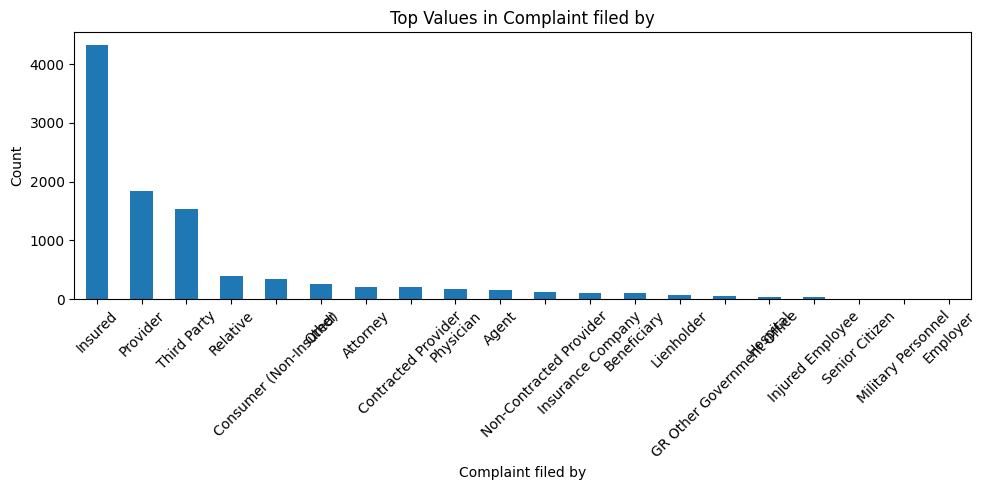

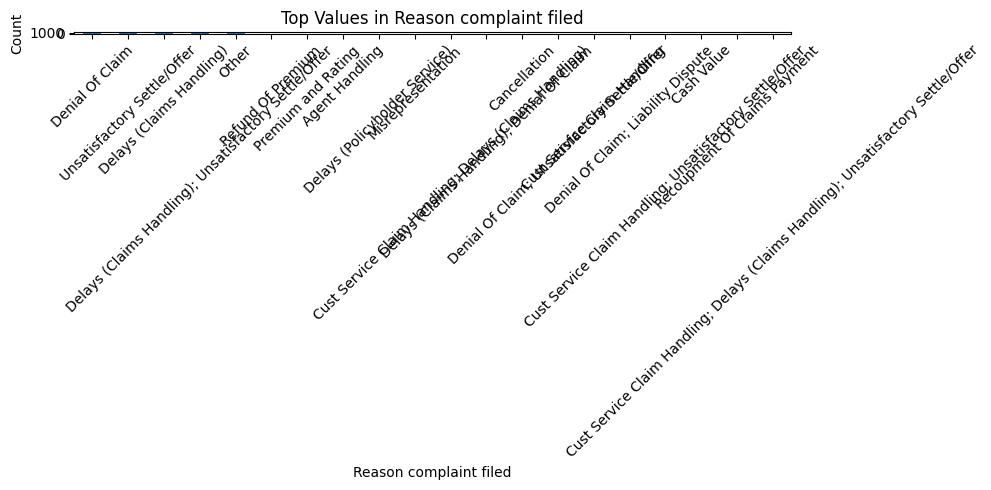


Approx sample memory usage: 9.36 MB


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your large CSV
csv_file = "/home/neubauer/src/pollock-offsite/data/csv_storm/csv/Insurance_complaints__All_data.csv"

# Read a sample first (fast inspection)
sample = pd.read_csv(csv_file, nrows=10000)

# Basic info
print(sample.head())
print(sample.info())
print(sample.describe(include='all'))

# -----------------------------
# 1. Missing values overview
# -----------------------------
missing = sample.isnull().sum()
missing = missing[missing > 0]

if not missing.empty:
    plt.figure(figsize=(12, 6))
    missing.sort_values(ascending=False).plot(kind='bar')
    plt.title("Missing Values per Column")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 2. Numeric distributions
# -----------------------------
numeric_cols = sample.select_dtypes(include='number').columns

for col in numeric_cols[:6]:   # limit to first 6 numeric columns
    plt.figure(figsize=(8, 4))
    sample[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3. Correlation heatmap
# -----------------------------
if len(numeric_cols) > 1:
    corr = sample[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect='auto')
    plt.colorbar(label="Correlation")

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4. Categorical column counts
# -----------------------------
cat_cols = sample.select_dtypes(include='object').columns

for col in cat_cols[:3]:   # limit to first 3 categorical columns
    top_counts = sample[col].value_counts().head(20)

    plt.figure(figsize=(10, 5))
    top_counts.plot(kind='bar')
    plt.title(f"Top Values in {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 5. Memory usage
# -----------------------------
mem = sample.memory_usage(deep=True).sum() / 1024**2
print(f"\nApprox sample memory usage: {mem:.2f} MB")

Complaint number,Complaint filed against,Complaint filed by,Reason complaint filed,Confirmed complaint,How resolved,Received date,Closed date,Complaint type,Coverage type,Coverage level,Others involved,Respondent ID,Respondent Role,Respondent type,Complainant type,Keywords
1,METROPOLITAN LIFE INSURANCE COMPANY,Relative,Cust Service Claim Handling,No,Other,06/12/2012,07/25/2012,"Life, Accident and Health",Life & Annuity,Individual Life,,13191,Ins Co - Licensed/Active,Organization,INDV,
2,AETNA LIFE INSURANCE COMPANY,Provider,Delays (Claims Handling),No,Information Furnished,06/21/2012,08/01/2012,"Life, Accident and Health",Accident and Health,Group A&H,Insured,245,Ins Co - Licensed/Active,Organization,ORG,
3,"BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISION OF HEALTH CARE SERVICE CORPORATION",Provider,Denial Of Claim,No,Other,06/11/2012,07/30/2012,"Life, Accident and Health",Accident and Health,Group A&H,,10047,Ins Co - Licensed/Active,Organization,ORG,
4,"BLUE CROSS AND BLUE SHIELD OF T

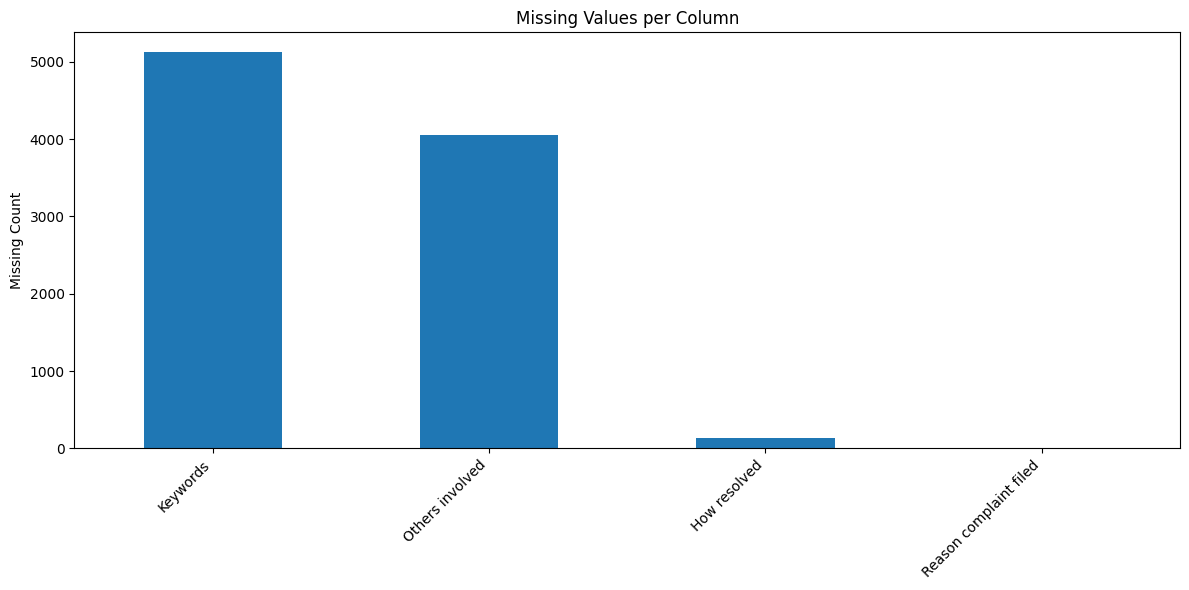

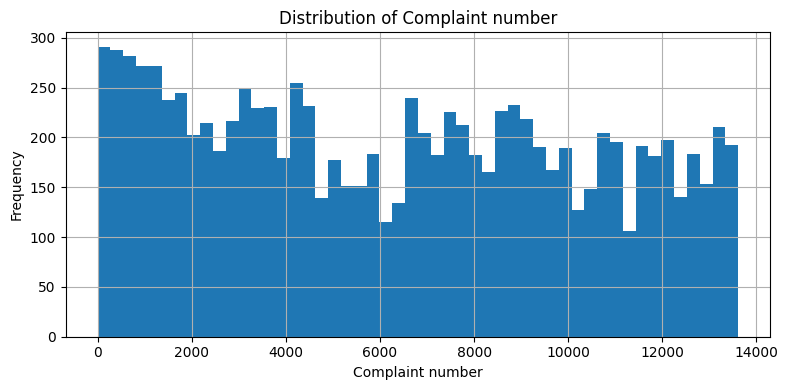

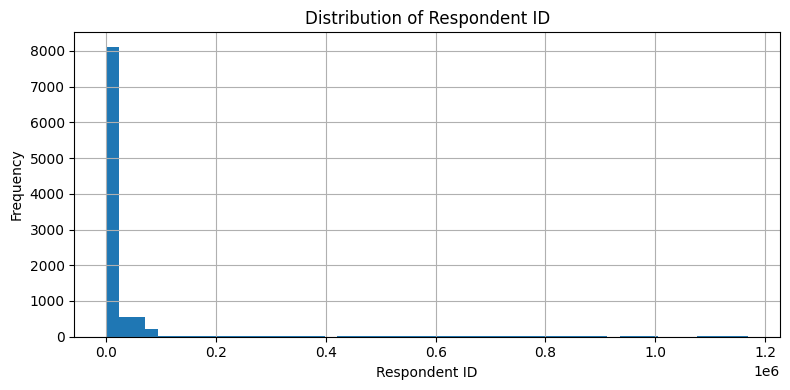

/tmp/ipykernel_1325350/849038543.py:81: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns
/tmp/ipykernel_1325350/849038543.py:91: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


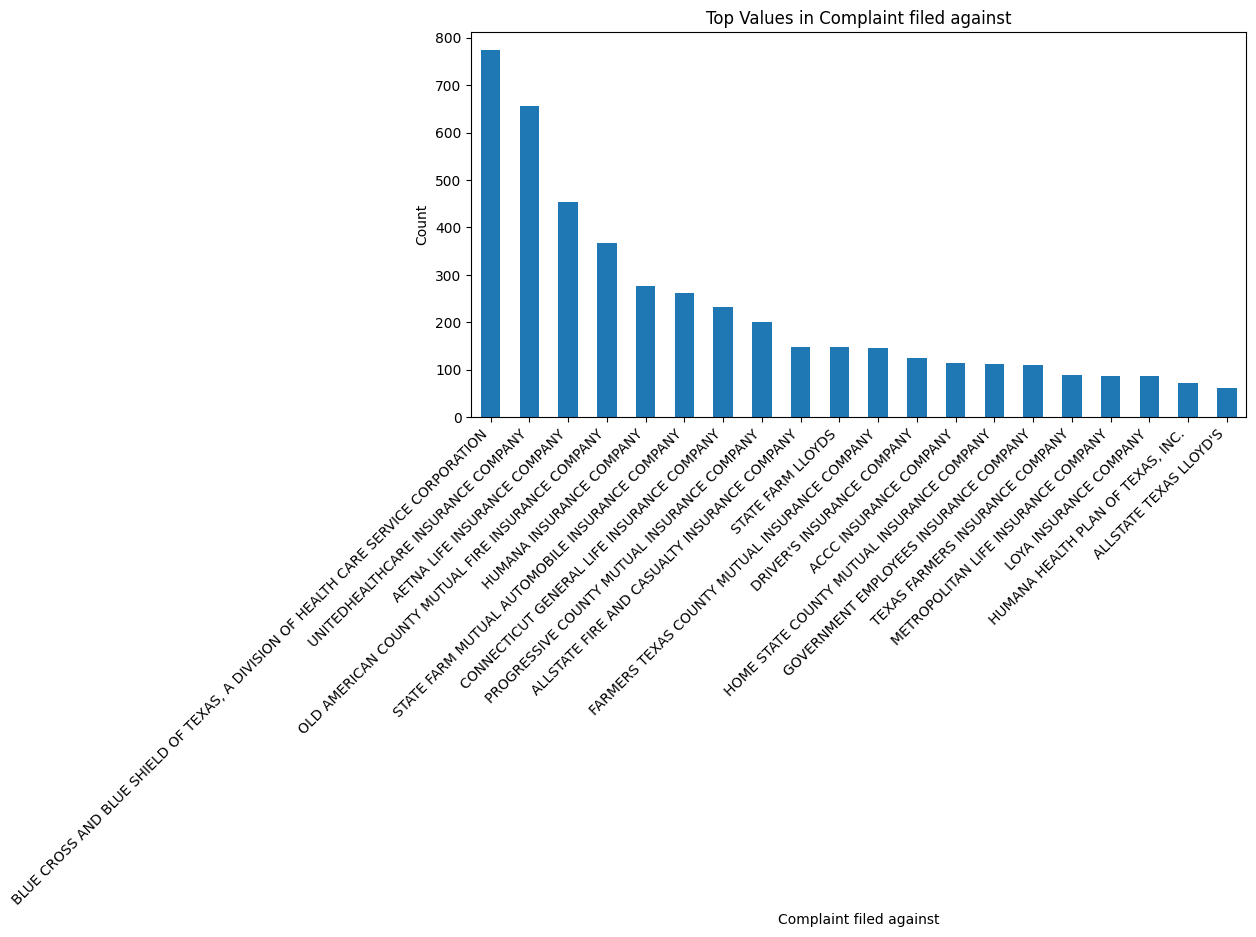

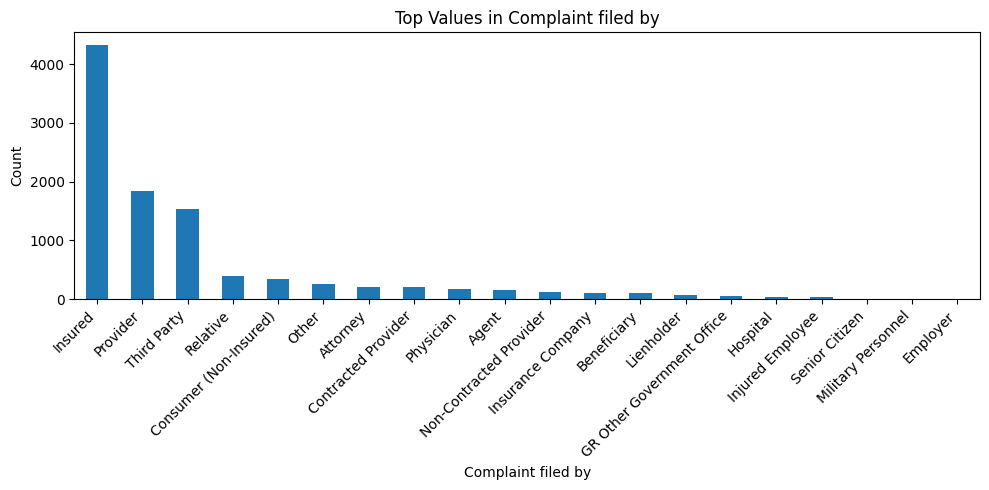

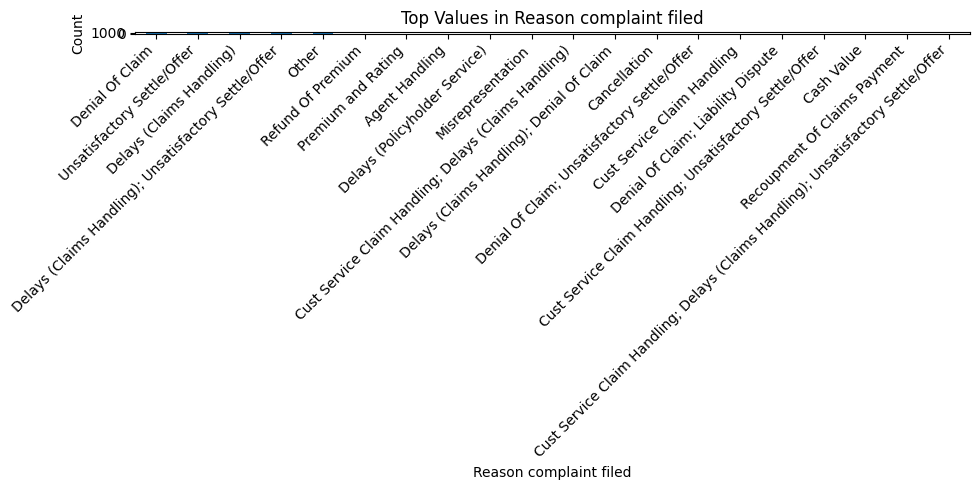

In [6]:
import csv
import pandas as pd
import matplotlib.pyplot as plt

csv_file = "/home/neubauer/src/pollock-offsite/data/csv_storm/csv/Insurance_complaints__All_data.csv"

# -----------------------------
# 1. Preview the raw file
# -----------------------------
with open(csv_file, "r", encoding="utf-8", errors="replace") as f:
    for i in range(10):
        print(f.readline().rstrip())

# -----------------------------
# 2. Detect likely delimiter
# -----------------------------
with open(csv_file, "r", encoding="utf-8", errors="replace") as f:
    sample_text = f.read(50_000)

sniffer = csv.Sniffer()
dialect = sniffer.sniff(sample_text)

print("Detected delimiter:", repr(dialect.delimiter))
print("Detected quotechar:", repr(dialect.quotechar))

# -----------------------------
# 3. Load a preview with pandas
# -----------------------------
df = pd.read_csv(
    csv_file,
    sep=dialect.delimiter,
    nrows=10_000,
    low_memory=False,
    on_bad_lines="warn"
)

print("\nPreview:")
print(df.head(20))

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nSummary:")
print(df.describe(include="all"))

# -----------------------------
# 4. Visual preview of missingness
# -----------------------------
missing = df.isna().sum()
missing = missing[missing > 0]

if not missing.empty:
    plt.figure(figsize=(12, 6))
    missing.sort_values(ascending=False).plot(kind="bar")
    plt.title("Missing Values per Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 5. Numeric distributions
# -----------------------------
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols[:6]:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 6. Categorical previews
# -----------------------------
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols[:3]:
    top_counts = df[col].value_counts(dropna=False).head(20)

    plt.figure(figsize=(10, 5))
    top_counts.plot(kind="bar")
    plt.title(f"Top Values in {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()